## Imports

In [ ]:
1/0

ZeroDivisionError: division by zero

In [1]:
%cd ~/projects/entityrepresentations
!ls

/home/morand/projects/entityrepresentations
EntityRepresentations.ipynb	TaskVec_l20_e60.pth
jobs				TaskVec_phi-1_5_l20_e5.pth
LabelExtractor.py		TaskVec_pythia-2.8b_l25_e1.pth
__pycache__			TaskVec_pythia-2.8b_l25_e44.pth
README.md			utils.py
TaskVec_gpt2-small_l10_e15.pth	xp
TaskVec_gpt2-small_l8_e50.pth


/home/morand/reimplems/taskVectorsHendel/env/lib/python3.10/site-packages/IPython/core/magics/osm.py:393: UserWarning: This is now an optional IPython functionality, using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})
/home/morand/reimplems/taskVectorsHendel/env/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [141]:
import transformer_lens as tl 
from transformer_lens import HookedTransformer, patching
from importlib import reload
import torch, gc
import torch.nn as nn
from tqdm import tqdm
#our own module
import utils 
reload(utils)

<module 'utils' from '/home/morand/projects/entityrepresentations/utils.py'>

In [3]:
gc.collect()
torch.cuda.empty_cache()

## Model Loading

In [4]:
# Load a model (eg GPT-2 Small)
model_name = "bloom-3b" #crashed
model_name = "pythia-2.8b" #ok !
model_name = "gpt2-xl"
model_name = "gpt2-small"
model_name = "phi-1_5"
model = HookedTransformer.from_pretrained(model_name)
model.eval()
dim = model.QK.shape[-1]
print(model)

/home/morand/reimplems/taskVectorsHendel/env/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loaded pretrained model phi-1_5 into HookedTransformer
HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint()
  (blocks): ModuleList(
    (0-23): 24 x TransformerBlock(
      (ln1): LayerNormPre(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (ln2): LayerNormPre(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (attn): Attention(
        (hook_k): HookPoint()
        (hook_q): HookPoint()
        (hook_v): HookPoint()
        (hook_z): HookPoint()
        (hook_attn_scores): HookPoint()
        (hook_pattern): HookPoint()
        (hook_result): HookPoint()
        (hook_rot_k): HookPoint()
        (hook_rot_q): HookPoint()
      )
      (mlp): MLP(
        (hook_pre): HookPoint()
        (hook_post): HookPoint()
      )
      (hook_attn_in): HookPoint()
      (hook_q_input): HookPoint()
      (hook_k_input): HookPoint()
      (hook_v_input): HookPoint()
      (hook_mlp_in): HookPoint()
      (hook_

In [5]:
# print hooks
test_prompt = "The quick brown fox jumped over the lazy dog"
print("Num tokens:", len(model.to_tokens(test_prompt)[0]))
def print_name_shape_hook_function(activation, hook):
    print(hook.name, activation.shape)
not_in_late_block_filter = lambda name: name.startswith("blocks.0.") or not name.startswith("blocks")

model.run_with_hooks(
    test_prompt,
    return_type=None,
    fwd_hooks=[(not_in_late_block_filter, print_name_shape_hook_function)],
)

Num tokens: 10
hook_embed torch.Size([1, 10, 2048])
blocks.0.hook_resid_pre torch.Size([1, 10, 2048])
blocks.0.ln1.hook_scale torch.Size([1, 10, 1])
blocks.0.ln1.hook_normalized torch.Size([1, 10, 2048])
blocks.0.ln1.hook_scale torch.Size([1, 10, 1])
blocks.0.ln1.hook_normalized torch.Size([1, 10, 2048])
blocks.0.ln1.hook_scale torch.Size([1, 10, 1])
blocks.0.ln1.hook_normalized torch.Size([1, 10, 2048])
blocks.0.attn.hook_q torch.Size([1, 10, 32, 64])
blocks.0.attn.hook_k torch.Size([1, 10, 32, 64])
blocks.0.attn.hook_v torch.Size([1, 10, 32, 64])
blocks.0.attn.hook_rot_q torch.Size([1, 10, 32, 64])
blocks.0.attn.hook_rot_k torch.Size([1, 10, 32, 64])
blocks.0.attn.hook_attn_scores torch.Size([1, 32, 10, 10])
blocks.0.attn.hook_pattern torch.Size([1, 32, 10, 10])
blocks.0.attn.hook_z torch.Size([1, 10, 32, 64])
blocks.0.hook_attn_out torch.Size([1, 10, 2048])
blocks.0.ln2.hook_scale torch.Size([1, 10, 1])
blocks.0.ln2.hook_normalized torch.Size([1, 10, 2048])
blocks.0.mlp.hook_pre tor

In [6]:
#test if we get the right hook name
replace_hook_name = tl.utils.get_act_name('embed')
print(replace_hook_name)

hook_embed


## Atomic Tests

In [ ]:
prompt, tok = "When Bob and France went to the store, Bob asked"            , 3
prompt, tok = "When Mary and Bob went to the store, Bob asked"              , 3
prompt, tok = "the French Iron King, aka '"                                 , 4
prompt, tok = "Alan Bean was an American astronaut, born on March 15, 1932 in Wheeler, Texas. He received a Bachelor of Science degree at the University of \
Texas at Austin in 1955 and was chosen by NASA in 1963. Alan Bean was a"   , 44
prompt, tok = "Alan Bean was an ", 2
prompt, tok = "Barack Obama was an ", 3
prompt, tok = "the molecule HU765DGB introduced herself: 'hi, my name is"   , 7
prompt, tok = "The Eiffel Tower"                                           , 5
prompt, tok = "The Empire State Building is a great monument"               , 4
prompt, tok = "Man of steel, commonly known as"                             , 3


### Test Generation

In [8]:
res = model.generate(prompt, max_new_tokens=20, temperature=0, return_type="str")
print(res)
# model.to_str_tokens(res)


  0%|          | 0/20 [00:00<?, ?it/s]

Man of steel, commonly known as the Iron Man, has been making waves in the world of superheroes. The Iron Man is a fictional


### Extract representation at given layer

In [ ]:
toks = model.to_str_tokens(prompt)
for i,t  in enumerate(toks): print(i, "\t", t, "  <--" if i==tok else "")

repr = utils.get_representation(model,
                                layer=20,
                                tokens=model.to_tokens(prompt),
                                token_inds=[tok],
                                verbose=True)

0 	 <|endoftext|> 
1 	 Man 
2 	  of 
3 	  steel   <--
4 	 , 
5 	  commonly 
6 	  known 
7 	  as 
extract representation of tokens [3] at hook blocks.10.hook_resid_post


### Regererate Label from rep
Here we can observe that the last subject's token contain enough information to identify the subject.

In [10]:
utils.generate_from_repr(model, 
                         repr, 
                         retr_prompt="_ is located in the city of", 
                         do_sample=True,)

['<|endoftext|>_ is located in the city of Pittsburgh, Pennsylvania. The steel mill is a massive']


# Datasets


## WebNLG

### Import

In [137]:
import torch
import numpy as np
from torch.utils.data import DataLoader, Dataset
from datasets import load_dataset

# Load WebNLG dataset
dataset = load_dataset("web_nlg", "release_v3.0_en")


In [138]:
N_train = len(dataset["train"])
print("training dataset: ",N_train)
print("random sample: ")
item = dataset["train"][np.random.randint(N_train)]
# print(item["text"])
item

training dataset:  13211
random sample: 


{'category': 'SportsTeam',
 'size': 1,
 'eid': 'Id71',
 'original_triple_sets': {'otriple_set': [['A.S._Roma | chairman | James_Pallotta']]},
 'modified_triple_sets': {'mtriple_set': [['A.S._Roma | chairman | James_Pallotta']]},
 'shape': '(X (X))',
 'shape_type': 'NA',
 'lex': {'comment': ['good', 'good', 'good'],
  'lid': ['Id1', 'Id2', 'Id3'],
  'text': ['The chairman of the A.S. Roma is James Pallotta.',
   'James Pallotta is the chairman of A.S. Roma.',
   "A.S. Roma's chairman is James Pallotta."],
  'lang': ['', '', '']},
 'test_category': '',
 'dbpedia_links': [],
 'links': []}

### Build custom Dataset

In [142]:
#optionnal, filter categories from datset
cat = ['Food'] #Cats to remove
cat = None
if cat :
    dataset["train"] = [item for item in dataset["train"] if item["category"] not in cat]
    dataset["test"] = [item for item in dataset["test"] if item["category"] not in cat]

# Create dataset instances
train_dataset = utils.WebNLGDataset(dataset['train'], max_ent_length=20)
test_dataset = utils.WebNLGDataset(dataset['test'])

print("train length:", len(train_dataset))
print("test length:", len(test_dataset))
print("ex sample:", train_dataset[np.random.randint(len(train_dataset))])

train length: 37644
test length: 13015
ex sample: {'entity': 'American', 'text': "Abraham A. Ribicoff's nationality is American. American", 'id': 3676}


In [8]:
#print random sample
train_dataset[np.random.randint(N_train)]

{'entity': '1. FC Köln',
 'text': 'Peter Stöger is at the FK Austria Wien club and manages 1 FC Koln. 1. FC Köln',
 'id': 9484}

### Augment Dataset with subject representations

In [143]:
layer = 15 #layer where to extract representations
b_size = 60
print("Augmenting Train set with subject representations ... ")
train_dataset.augment_with_repr(model, layer, batch_size=b_size,first_token_only=True)
print("Augmenting Test set with subject representations ... ")
test_dataset.augment_with_repr(model, layer, batch_size=b_size,first_token_only=True)
print("Extraction of subjects representatons Done !\n")

Augmenting Train set with subject representations ... 


100%|█████████████████████████████████████████████████████████████████████████████| 628/628 [07:43<00:00,  1.35it/s]


Augmenting Test set with subject representations ... 


100%|█████████████████████████████████████████████████████████████████████████████| 217/217 [04:02<00:00,  1.12s/it]

Extraction of subjects representatons Done !



In [198]:
print(str(train_dataset[torch.randint(len(train_dataset),(1,))]).replace(", '", ",\n'"))

{'entity': 'English language',
'text': 'Atlas II originates from the United States, where english is spoken and the capital is Washington D.C. Asian Americans are an ethnic group in the U.S. where all people are Americans. English language',
'id': 34188,
'representation': tensor([ 1.6265,  1.6519, -6.1563,  ..., -0.8137, -0.1799,  1.3136]),
'prompt': '_ > English'}


In [11]:
#ex sample from final dataset
test_dataset[67]["entity"]

'Alan Shepard'

### Inspect Dataset

In [12]:
import numpy as np
# get the first tokens of all entities
first_tokens = []
for i in range(len(train_dataset)):
    first_tokens.append(model.to_str_tokens(train_dataset[i]["entity"])[1])

# get counts of each token
unique, counts = np.unique(first_tokens, return_counts=True)

# sort by counts
sorted_tokens = sorted(zip(unique, counts), key=lambda x: x[1], reverse=True)
sorted_tokens[:30]


[('A', 2697),
 ('United', 2188),
 ('B', 1179),
 ('Al', 974),
 ('Ab', 644),
 ('S', 601),
 ('G', 519),
 ('New', 444),
 ('D', 429),
 ('English', 422),
 ('C', 387),
 ('F', 386),
 ('Washington', 379),
 ('M', 356),
 ('Alan', 354),
 ('J', 346),
 ('H', 337),
 ('Aaron', 334),
 ('K', 305),
 ('R', 299),
 ('P', 269),
 ('Ak', 259),
 ('Ar', 255),
 ('African', 242),
 ('N', 242),
 ('Ale', 241),
 ('L', 226),
 ('Ap', 224),
 ('V', 217),
 ('Ant', 214)]

# Training

In [147]:
#utils 
from utils import get_replace_with_rep_hook

def eval_model(model, TaskVec, test_loader, prepend_bos=True):
    """
    Evaluate the model on a given test_loader
    """
    b_count = 0
    m_acc = 0
    replace_hook_name = tl.utils.get_act_name('embed') #pos_embed ?
    eos_tok_str = model.tokenizer.eos_token
    rep_idx = 1 if prepend_bos else 0
    taskVec_idx = rep_idx + 1

    with torch.no_grad():
        for batch in tqdm(test_loader):
            b_count += 1
            # print(str(batch).replace("', ", "'\n"))
            prompts = batch["prompt"]
            # prompts = ["_ > " + ent + eos_tok_str for ent in batch["entity"]] # [ _ > ent1, _ > ent2, ...

            reps = batch["representation"].squeeze(1)
            b_taskVec = TaskVec.repeat(len(prompts),1)

            tokens = model.to_tokens(prompts, prepend_bos=prepend_bos,)
            inputs = tokens[:,:]
            targets = tokens[:,2:] #don't take the '<eos>','_' ,'called'' tokens into account

            # print(inputs, targets)
            logits = model.run_with_hooks(
                    inputs,
                    return_type = "logits",
                    fwd_hooks=[
                        (replace_hook_name, get_replace_with_rep_hook(reps, rep_idx)), # replace '_' by the subject Representation
                        (replace_hook_name, get_replace_with_rep_hook(b_taskVec, taskVec_idx)) # replace 'called' by TaskVec Representation
                        ]
                ,)

            # LM Loss and optimization 
            acc = tl.utils.lm_accuracy(logits[:,2:,:], targets) # implementation here
            
            m_acc += acc.item()

    return m_acc / b_count


### Train Label Extraction task vector

In [17]:
dim = model.QK.shape[-1]
prepend_bos = True
# create Task Vector
TaskVec = torch.normal(mean=0, std=1.0, size=(1,dim), requires_grad=True)
losses = []
accs = []
# TaskVec = torch.ones((1,d), requires_grad=True)

for param in model.parameters():
    param.requires_grad = False

Now we train our Taskvector in order to retreive the labels. 
We use the cross entropy loss, *i.e* : $$\ell(x,y)=L=\{l_1,\ldots,l_N\}^\top,\quad l_n=-w_{y_n}\log\frac{\exp(x_{n,y_n})}{\sum_{c=1}^C\exp(x_{n,c})}\cdot1$$
The TransformerLens implementation is [here](https://github.com/TransformerLensOrg/TransformerLens/blob/f4287b68d544b5fe1221739a4f3c2424eccf7d31/transformer_lens/utils.py#L115), **Warning**, it takes as input all the logits, and perform the shift **afterwards** !

In [220]:
#Training params
lr = 1e-3
batch_size = 60
epochs = 5

rep_idx = 1 if prepend_bos else 0 
taskVec_idx = rep_idx + 1
eos_tok = model.tokenizer.eos_token_id
eos_tok_str = model.tokenizer.eos_token

padding_tok = model.tokenizer.eos_token_id
replace_hook_name = tl.utils.get_act_name('embed') #pos_embed for gpt2 ... 

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=200, shuffle=True)
optim = torch.optim.Adam([TaskVec], lr=lr)
# optim = torch.optim.SGD([TaskVec], lr=lr)
# criterion = nn.CrossEntropyLoss()
gc.collect()
torch.cuda.empty_cache()

for epoch in range(epochs):
    b_count = 0
    m_loss = 0
    for batch in tqdm(train_dataloader):
        b_count += 1
        # print(str(batch).replace("', ", "'\n"))
        # prompts = ["_ > " + ent + eos_tok_str for ent in batch["entity"]] # [ _ > ent1, _ > ent2, ...
        prompts = batch["prompt"]
        # optionnally cut to keep only the first token of each entity
        # prompts = model.to_str_tokens(prompts, prepend_bos=False,)
        # prompts = ["".join(p[:3]) for p in prompts]
        # print(prompts)
        # print(batch["text"])
        reps = batch["representation"].squeeze(1)
        b_taskVec = TaskVec.repeat(len(prompts),1)
        tokens = model.to_tokens(prompts, prepend_bos=prepend_bos,)
        # print(tokens)
        # break

        inputs = tokens[:,:]
        targets = tokens[:,2:] #don't take the '<eos>','_' ,'called'' tokens into account

        # print(inputs, targets)
        logits = model.run_with_hooks(
                inputs,
                return_type = "logits",
                fwd_hooks=[
                    (replace_hook_name, get_replace_with_rep_hook(reps, rep_idx)), # replace '_' by the subject Representation
                    (replace_hook_name, get_replace_with_rep_hook(b_taskVec, taskVec_idx)) # replace 'called' by TaskVec Representation
                    ]
            ,)

        # LM Loss and optimization 
        loss = model.loss_fn(logits[:,2:,:], targets)
        loss.backward()
        optim.step()
        optim.zero_grad()
        m_loss += loss.item()

    losses.append(m_loss / b_count)
    accs.append(eval_model(model,TaskVec,test_loader=test_dataloader))
    print(f" Epoch {len(losses)}, Language modeling loss: {losses[-1]:.3f}, Test Acc: {accs[-1]:.3f}")
        

100%|███████████████████████████████████████████████████████████████████████████████| 66/66 [00:13<00:00,  4.72it/s]


 Epoch 26, Language modeling loss: 2.007, Test Acc: 0.327


100%|███████████████████████████████████████████████████████████████████████████████| 66/66 [00:14<00:00,  4.71it/s]


 Epoch 27, Language modeling loss: 2.009, Test Acc: 0.324


100%|███████████████████████████████████████████████████████████████████████████████| 66/66 [00:13<00:00,  4.74it/s]


 Epoch 28, Language modeling loss: 2.007, Test Acc: 0.326


100%|███████████████████████████████████████████████████████████████████████████████| 66/66 [00:14<00:00,  4.71it/s]


 Epoch 29, Language modeling loss: 2.006, Test Acc: 0.325


100%|███████████████████████████████████████████████████████████████████████████████| 66/66 [00:14<00:00,  4.69it/s]

 Epoch 30, Language modeling loss: 2.004, Test Acc: 0.323


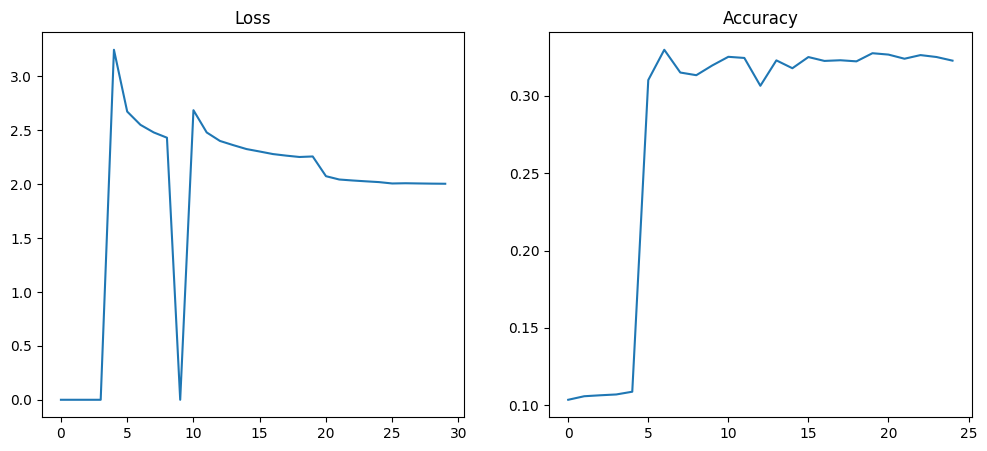

In [274]:
import matplotlib.pyplot as plt

# Create a figure and two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(losses)
ax2.plot(accs)
ax1.set_title("Loss")
ax2.set_title("Accuracy")
plt.show()

In [222]:
first_token_only = True
task = "LabelExtrator" if first_token_only else "FirstTokenExtractor"
fileName = f'{task}_{model_name}_l{layer}_e{len(losses)}.pth'
torch.save(TaskVec, fileName)

### Testing the model

In [149]:
TaskVec = torch.load(fileName)

In [275]:
test_dataloader = DataLoader(test_dataset, batch_size=500, shuffle=True)
acc = eval_model(model, TaskVec, test_dataloader)
print(f" Evaluation accuracy on test set: {acc:.3f}")
    

100%|███████████████████████████████████████████████████████████████████████████████| 27/27 [00:11<00:00,  2.37it/s]

 Evaluation accuracy on test set: 0.330


In [ ]:
dataset = test_dataset
ind = np.random.randint(len(dataset))
print(dataset[ind]["text"])
print(dataset[ind]["entity"])
s = dataset[ind]["representation"].view(1,-1)

# s = repr
utils.generate_from_repr(model, s, TaskVec, retr_prompt="_ >", max_tokens=5)

Olga Nikolaevna Bondareva was born on April 27, 1937. A student of Leningrad State University, Bondareva is known for Bondareva-Shapley Theorem. Bondareva died in Saint Petersburg. Olga Bondareva
Olga Bondareva
['<|endoftext|>_ > Ab<|endoftext|>']
